# Sequence Generation Algorithm from https://arxiv.org/abs/2005.05581

In [152]:
import numpy as np
from typing import List
import heapq
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Logical Base Gate Sets

In [3]:
def cost_function1(n: int) -> int:
    if (n == 3):
        return 1
    else:
        return (4 - 3*2**(3-n))

In [4]:
def rz_gate(theta: float):
    return np.array([[np.exp(-1j * theta/2), 0], [0, np.exp(1j * theta/2)]])

In [5]:
# Creating the Tau gate sets
def odd_k(denom: int) -> List[int]:
    k_list = []
    highest = denom//2 - 1
    k_list = list(range(-highest, highest+1, 2))
    return k_list
    
def tau_set(n: int):
    tau = []
    denom = 2**(n-1)
    k_list = odd_k(denom)
    cost = cost_function1(n)
    for k in k_list:
        gate = rz_gate(k*np.pi/denom)
        tau.append({"gate": gate, "cost": cost, "name": f"Rz({k}*π/{denom})"})
    return tau

In [6]:
# Creating the logical base gate set number 1
set1 = []

pauli_x = np.array([[0, 1], [1, 0]])
set1.append({"gate": pauli_x, "cost": 0, "name": "X"})

pauli_y = np.array([[0, -1j], [1j, 0]])
set1.append({"gate": pauli_y, "cost": 0, "name": "Y"})

pauli_z = np.array([[1, 0], [0, -1]])
set1.append({"gate": pauli_z, "cost": 0, "name": "Z"})

hadamard = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]])
set1.append({"gate": hadamard, "cost": 0, "name": "H"})

s_gate = rz_gate(np.pi/2)
set1.append({"gate": s_gate, "cost": 0, "name": "S"})

sdg_gate = rz_gate(-np.pi/2)
set1.append({"gate": sdg_gate, "cost": 0, "name": "Sdg"})

set1 = set1 + tau_set(3)
print(set1)


[{'gate': array([[0, 1],
       [1, 0]]), 'cost': 0, 'name': 'X'}, {'gate': array([[ 0.+0.j, -0.-1.j],
       [ 0.+1.j,  0.+0.j]]), 'cost': 0, 'name': 'Y'}, {'gate': array([[ 1,  0],
       [ 0, -1]]), 'cost': 0, 'name': 'Z'}, {'gate': array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]]), 'cost': 0, 'name': 'H'}, {'gate': array([[0.70710678-0.70710678j, 0.        +0.j        ],
       [0.        +0.j        , 0.70710678+0.70710678j]]), 'cost': 0, 'name': 'S'}, {'gate': array([[0.70710678+0.70710678j, 0.        +0.j        ],
       [0.        +0.j        , 0.70710678-0.70710678j]]), 'cost': 0, 'name': 'Sdg'}, {'gate': array([[0.92387953+0.38268343j, 0.        +0.j        ],
       [0.        +0.j        , 0.92387953-0.38268343j]]), 'cost': 1, 'name': 'Rz(-1*π/4)'}, {'gate': array([[0.92387953-0.38268343j, 0.        +0.j        ],
       [0.        +0.j        , 0.92387953+0.38268343j]]), 'cost': 1, 'name': 'Rz(1*π/4)'}]


In [7]:
# Creating the other logical base sets
set2 = set1 + tau_set(4)
set3 = set2 + tau_set(5)
set4 = set3 + tau_set(6)
set5 = set4 + tau_set(7)

In [8]:
def remove_global_phase(U):
    det = np.linalg.det(U)
    if (det == 0):
        return U
    elif (det < 0):
        s = 1j * np.sqrt(abs(det))
    else:
        s = np.sqrt(det)
        
    return U / s

# Finding axis of rotation for an arbitrary single qubit unitary

In [9]:
identity = np.eye(2, dtype=complex)
print(identity)

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [10]:
def Lie_generator(U, eps: float = 1e-12):
    if (np.array_equal(identity, U)):
        return (0, 0, 0)
    
    U = remove_global_phase(U)
    theta = 2*np.arccos(np.trace(U)/2)
    
    denom = np.sin(theta/2.0)
    if (abs(denom) < eps):
        return (0, 0, 0)
    
    n1 = 1j * np.trace(pauli_x @ U) / (2*np.sin(theta/2))
    n2 = 1j * np.trace(pauli_y @ U) / (2*np.sin(theta/2))
    n3 = 1j * np.trace(pauli_z @ U) / (2*np.sin(theta/2))
    
    alpha = np.real(theta/2 * n1)
    beta = np.real(theta/2 * n2)
    gamma = np.real(theta/2 * n3)
    
    return (alpha, beta, gamma)

In [11]:
print(Lie_generator(pauli_x))

(1.5707963267948966, 0.0, 0.0)


In [12]:
def key_from_U(U: np.ndarray, grid: float = 1e-9):
    a,b,c = Lie_generator(U)
    return (np.round(a/grid), np.round(b/grid), np.round(c/grid))
    return (int(np.round(a/grid)), int(np.round(b/grid)), int(np.round(c/grid)))

In [13]:
print(key_from_U(pauli_x))

(1570796327.0, 0.0, 0.0)


# Sequence Database

In [14]:
class SequenceDB:
    def __init__(self):
        self.vecs = []   # (α,β,γ)
        self.units = []  # 2x2
        self.costs = []
        self.seqs = []
        
    def add(self, v, U, cost, seq):
        self.vecs.append(tuple(float(x) for x in v))
        self.units.append(np.array(U, dtype=complex))
        self.costs.append(float(cost))
        self.seqs.append(str(seq))

# Sequence Generating Algorithm

In [15]:
# Given a base gate set and a max cost, this functions finds all the possible combinations of gates that has a T-cost of less than or equal to the max cost. 
def generate_sequences(base_gate_set, max_cost: float):
    db = SequenceDB()
    
    nodes_U = [identity]
    nodes_seq = [""]
    heap = [(0.0, 0)]
    unique = set()
    best_cost = {key_from_U(identity): 0.0}
    
    while heap:
        cost_i, i = heapq.heappop(heap)
        if (cost_i > max_cost):
            continue
        
        key_i = key_from_U(nodes_U[i])
        if key_i in unique:
            continue
        unique.add(key_i)
        
        v_i = Lie_generator(nodes_U[i])
            
        db.add(v_i, nodes_U[i], cost_i, nodes_seq[i])
        
        for base_gate in base_gate_set:
            new_cost = cost_i + base_gate["cost"]
            if (new_cost > max_cost):
                continue
            
            U_child = base_gate["gate"] @ nodes_U[i]
            key_c = key_from_U(U_child)
            
            if new_cost < best_cost.get(key_c, float("inf")):
                best_cost[key_c] = new_cost
                nodes_U.append(U_child)
                nodes_seq.append(nodes_seq[i] + base_gate["name"])
                heapq.heappush(heap, (new_cost, len(nodes_U)-1))
            
    return db

In [26]:
db1 = generate_sequences(set1, 10)

/opt/miniconda3/lib/python3.13/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [27]:
db2 = generate_sequences(set2, 10)

In [28]:
db3 = generate_sequences(set3, 10)

In [29]:
db4 = generate_sequences(set4, 10)

In [30]:
db5 = generate_sequences(set5, 10)

In [21]:
print(len(db1.vecs))

147359


In [22]:
print(db1.vecs[100])
print(db1.units[100])
print(db1.costs[100])
print(db1.seqs[100])

(1.2518853720693344, 0.5185478996476066, -1.2518853720693344)
[[-0.27059805+0.65328148j -0.27059805-0.65328148j]
 [ 0.27059805-0.65328148j -0.27059805-0.65328148j]]
1.0
YRz(1*π/4)H


In [23]:
print(db5.vecs[12345])
print(db5.units[12345])
print(db5.costs[12345])
print(db5.seqs[12345])

(1.7777056752611562, 0.610723468808079, -0.6818850694377101)
[[-0.31015268-0.41573481j  0.80858229-0.27778512j]
 [ 0.80858229+0.27778512j  0.31015268-0.41573481j]]
4.5
XHRz(1*π/4)HRz(-1*π/4)HRz(1*π/8)HS


# Saving Results

In [16]:
import pickle, gzip
from pathlib import Path

In [17]:
def save_db_pickle(db, path: str):
    payload = {
        "vecs":  np.asarray(db.vecs,  dtype=float),     # (N,3)
        "units": np.asarray(db.units, dtype=complex),   # (N,2,2)
        "costs": np.asarray(db.costs, dtype=float),     # (N,)
        "seqs":  np.asarray(db.seqs,  dtype=object),    # (N,)
    }
    with gzip.open(path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_db_pickle(path: str) -> SequenceDB:
    with gzip.open(path, "rb") as f:
        d = pickle.load(f)
    db = SequenceDB()
    db.vecs  = [tuple(map(float, v)) for v in np.asarray(d["vecs"])]
    db.units = [np.array(U, dtype=complex) for U in np.asarray(d["units"])]
    db.costs = [float(c) for c in np.asarray(d["costs"])]
    db.seqs  = [str(s) for s in np.asarray(d["seqs"])]
    return db

In [19]:
path1 = Path.cwd() / "seqdb_set1_T10.pkl.gz"
path2 = Path.cwd() / "seqdb_set2_T10.pkl.gz"
path3 = Path.cwd() / "seqdb_set3_T10.pkl.gz"
path4 = Path.cwd() / "seqdb_set4_T10.pkl.gz"
path5 = Path.cwd() / "seqdb_set5_T10.pkl.gz"

In [ ]:
# Save data 
save_db_pickle(db1, path1)
save_db_pickle(db2, path2)
save_db_pickle(db3, path3)
save_db_pickle(db4, path4)
save_db_pickle(db5, path5)

In [20]:
# Unload data
db1 = load_db_pickle(path1)
db2 = load_db_pickle(path2)
db3 = load_db_pickle(path3)
db4 = load_db_pickle(path4)
db5 = load_db_pickle(path5)

# Finding Neighbors

In [113]:
def graph_distance(S, G) -> float:
    S_dagger = S.conj().T
    answer = np.sqrt((2 - abs(np.trace(S_dagger @ G))) / 2)
    return answer

In [114]:
# Generate random single-qubit rotations using the QR (Ginibre) method 
def random_rotations():
    Z = (np.random.normal(size=(2,2)) + 1j*np.random.normal(size=(2,2)))
    Q, R = np.linalg.qr(Z)
    D = np.diag(np.exp(-1j*np.angle(np.diag(R))))
    unitary = Q @ D 
    unitary = remove_global_phase(unitary)
    vector = Lie_generator(unitary)
    vector = [np.asarray(vector, dtype=float)]
    return unitary, vector

In [118]:
def k_nearest_neighbor(db, U_matrix, U_vector, k: int):
    V = np.asarray(db.vecs, dtype=float)
    nn = NearestNeighbors(n_neighbors=k, algorithm="kd_tree", metric="euclidean")
    nn.fit(V)
    
    euclidean_dist, idxs = nn.kneighbors(U_vector, return_distance=True)
    graph_dist = []
    for i in range(k):
        graph_dist.append(graph_distance(db.units[idxs[0,i]], U_matrix))
        
    return euclidean_dist, graph_dist, idxs

In [143]:
random_matrix, random_vector = random_rotations()

euclidean_dist1, graph_dist1, idxs1 = k_nearest_neighbor(db1, random_matrix, random_vector, 3)

In [145]:
print(graph_dist1)
test = [-np.log10(d) for d in graph_dist1]
print(test)

[0.02582889863944317, 0.025831663525100725, 0.030613320942734126]
[1.58789411202297, 1.5878476249335924, 1.5140895554443994]


In [150]:
print(idxs1)

[[45737 56013 47414]]


In [151]:
a = [db1.costs[i] for i in idxs1[0]]
print(a)

[9.0, 9.0, 9.0]


# Plotting

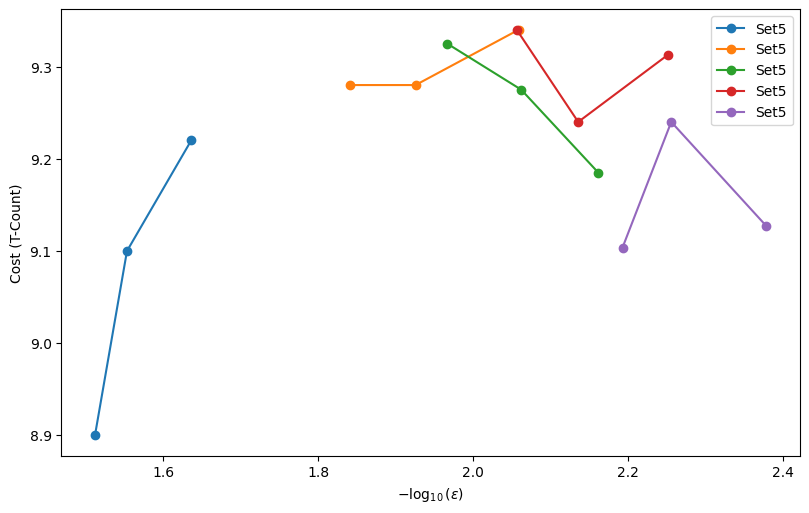

In [ ]:
dbs = [db1, db2, db3, db4, db5]
num_data_points = 3
num_random_rotations = 50

plt.figure(figsize=(8, 5))
for i, db in enumerate(dbs):
    graph_dist_sum = np.zeros(num_data_points, dtype=float)
    t_count_sum = np.zeros(num_data_points, dtype=float)
    for j in range(num_random_rotations):
        random_matrix, random_vector = random_rotations()
    
        euclidean_dist, graph_dist, idxs = k_nearest_neighbor(db, random_matrix, random_vector, num_data_points)
        graph_dist_sum += np.asarray(graph_dist, dtype=float)
        
        idx = np.asarray(idxs[0], dtype=int)
        costs = np.asarray(db.costs, dtype=float)
        t_count_sum += costs[idx]
    
    graph_dist = (graph_dist_sum / num_random_rotations).tolist()
    t_count = (t_count_sum / num_random_rotations).tolist()
    
    x_axis = [-np.log10(d) for d in graph_dist]
    y_axis = t_count
    
    #plt.plot(x_axis, y_axis, label=f'Set{i+1}', marker='o', linestyle='none')
    plt.plot(x_axis, y_axis, label=f'Set{i+1}', marker='o')

plt.legend()
plt.tight_layout()
plt.xlabel(r"$-\log_{10}(\epsilon)$")
plt.ylabel("Cost (T-Count)")
plt.show()